# SQL Analysis of Hospital Readmission Data

This notebook uses SQL queries to explore healthcare utilization patterns, patient readmission behavior, and risk-related clinical insights.

SQL was used to perform aggregations, filtering, ranking, and healthcare KPI analysis directly on the hospital dataset.

## Importing Libraries and Connecting to Database

In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv(
    "/drive/hospital-readmission-project/data/featured_hospital_data.csv"
)

def run_query(query):
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql(query, conn)

In [21]:
conn = sqlite3.connect("/drive/hospital-readmission-project/hospital_project.db")
df.to_sql("hospital_data", conn, if_exists="replace", index=False)
conn.commit()  
conn.close() 

In [22]:
conn = sqlite3.connect("/drive/hospital-readmission-project/hospital_project.db")

## Readmission Distribution Analysis

This query examines the distribution of hospital readmission outcomes across all patient encounters.

In [23]:
query = """

SELECT
    readmitted,
    COUNT(*) AS patient_count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM hospital_data),
        2
    ) AS percentage
FROM hospital_data
GROUP BY readmitted
ORDER BY patient_count DESC

"""

In [24]:
readmission_dist = pd.read_sql(query, conn)

readmission_dist

,readmitted,patient_count,percentage
0,NO,54864,53.91
1,>30,35545,34.93
2,<30,11357,11.16


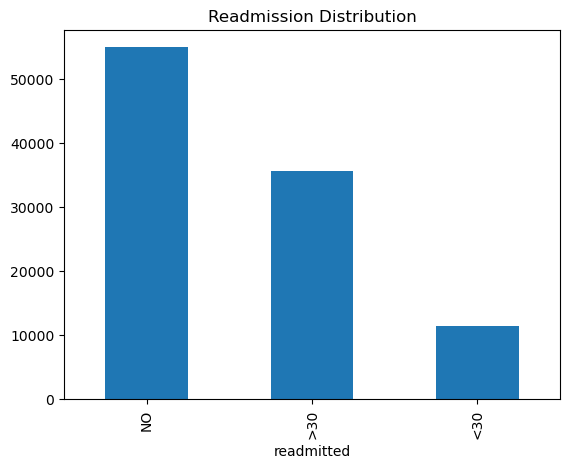

In [25]:
readmission_dist.plot(
    kind="bar",
    x="readmitted",
    y="patient_count",
    legend=False
)

plt.title("Readmission Distribution")

plt.show()

### Insight

The majority of patients were not readmitted within 30 days, while a smaller but clinically important subset experienced early readmission, highlighting potential opportunities for targeted post-discharge interventions and patient monitoring strategies.

## Average Length of Stay by Readmission Status

This analysis investigates whether hospital stay duration differs across readmission groups.

In [26]:
query = """

SELECT
    readmitted,
    ROUND(
        AVG(time_in_hospital),
        2
    ) AS avg_los
FROM hospital_data
GROUP BY readmitted
ORDER BY avg_los DESC

"""

pd.read_sql(query, conn)

,readmitted,avg_los
0,<30,4.77
1,>30,4.50
2,NO,4.25


### Insight

Patients experiencing early readmission demonstrated the highest average hospital stay duration, potentially indicating increased clinical severity or healthcare complexity.

## Patient Risk Category Distribution

This query evaluates the distribution of engineered patient risk categories within the dataset.

In [27]:
query = """

SELECT
    risk_category,
    COUNT(*) AS patient_count
FROM hospital_data
GROUP BY risk_category
ORDER BY patient_count DESC

"""

pd.read_sql(query, conn)

,risk_category,patient_count
0,Low,37970
1,High,33008
2,Medium,30788


### Insight

A substantial portion of patients were classified within medium and high-risk groups, supporting the importance of risk stratification in healthcare analytics workflows.

## Patients with Highest Healthcare Utilization

This analysis identifies patients with the highest combined healthcare utilization scores across inpatient, outpatient, and emergency services.

In [28]:
query = """

SELECT
    patient_nbr,
    utilization_score,
    risk_category
FROM hospital_data
ORDER BY utilization_score DESC
LIMIT 10

"""

pd.read_sql(query, conn)

,patient_nbr,utilization_score,risk_category
0,36645885,80,High
1,36645885,68,High
2,36645885,68,High
3,36645885,61,High
4,42466248,49,High
5,36645885,48,High
6,85551867,42,High
7,57714552,42,High
8,57714552,41,High
9,85551867,40,High


### Insight

Patients with the highest healthcare utilization scores were consistently classified as high-risk, reinforcing the relationship between healthcare usage intensity and patient complexity.

## Readmission Rates by Medical Specialty

This analysis evaluates which medical specialties demonstrate the highest proportion of early patient readmissions.

In [30]:
query = """

SELECT
    medical_specialty,
    COUNT(*) AS total_patients,

    SUM(
        CASE
            WHEN readmitted = '<30'
            THEN 1
            ELSE 0
        END
    ) AS readmitted_30,

    ROUND(
        SUM(
            CASE
                WHEN readmitted = '<30'
                THEN 1
                ELSE 0
            END
        ) * 100.0
        / COUNT(*),
        2
    ) AS readmission_rate

FROM hospital_data

GROUP BY medical_specialty

HAVING total_patients > 100

ORDER BY readmission_rate DESC

LIMIT 15

"""

specialty_readmission = pd.read_sql(query, conn)

specialty_readmission

,medical_specialty,total_patients,readmitted_30,readmission_rate
0,Hematology/Oncology,207,40,19.32
1,Oncology,348,66,18.97
2,Nephrology,1613,248,15.38
3,PhysicalMedicineandRehabilitation,391,60,15.35
4,Surgery-Vascular,533,74,13.88
5,Psychiatry,854,104,12.18
6,Family/GeneralPractice,7440,883,11.87
7,Unknown,49949,5781,11.57
8,InternalMedicine,14635,1646,11.25
9,Emergency/Trauma,7565,846,11.18


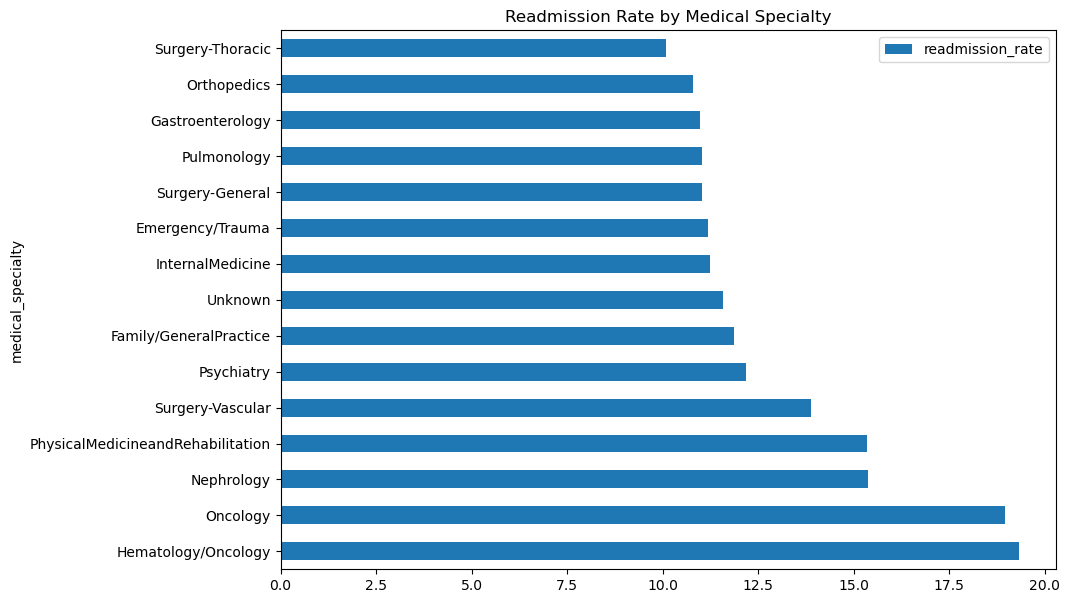

In [31]:
specialty_readmission.plot(
    kind="barh",
    x="medical_specialty",
    y="readmission_rate",
    figsize=(10,7)
)

plt.title("Readmission Rate by Medical Specialty")

plt.show()

### Insight

Several specialties demonstrated elevated readmission rates, particularly Hematology/Oncology and Nephrology, potentially reflecting the complexity and chronic nature of patient conditions managed within these departments.

# SQL Analysis Conclusion

The SQL analysis identified important healthcare patterns related to patient readmission, hospitalization duration, healthcare utilization, and specialty-specific readmission trends.

The findings demonstrate how SQL can support healthcare analytics workflows by transforming raw hospital data into actionable operational and clinical insights.